# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nishu-0618/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier


os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)


np.random.seed(42)
n_pages = 500

content_ids = [f"page_{i:04d}" for i in range(1, n_pages + 1)]
days_since_update = np.random.randint(15, 600, size=n_pages)
word_count = np.random.randint(400, 4500, size=n_pages)
pos_m1 = np.random.uniform(1.0, 30.0, size=n_pages)
pos_m2 = pos_m1 + np.random.normal(1.5, 2.0, size=n_pages)
imp_m1 = np.random.randint(50, 8000, size=n_pages)
clicks_m1 = (imp_m1 * np.random.uniform(0.01, 0.07, size=n_pages)).astype(int)
clicks_m2 = (clicks_m1 * np.random.uniform(0.4, 1.1, size=n_pages)).astype(int)


decay_prob = 1 / (1 + np.exp(-( (days_since_update / 250) + (pos_m2 / 12) - 2.8 )))
refresh_score = np.clip(decay_prob + np.random.normal(0, 0.05, size=n_pages), 0.01, 0.99)

df_playbook = pd.DataFrame({
    'content_id': content_ids,
    'clicks_m1': clicks_m1,
    'clicks_m2': clicks_m2,
    'imp_m1': imp_m1,
    'pos_m1': pos_m1,
    'pos_m2': pos_m2,
    'days_since_update': days_since_update,
    'word_count': word_count,
    'refresh_score': refresh_score
})


def assign_reason_and_action(row):
    if row['pos_m2'] >= row['pos_m1'] + 2.0 and row['pos_m1'] <= 20:
        return 'Rank Loss (Striking Distance)', 'Priority 1: Update metadata, refresh core stats, audit competitor headings.'
    elif row['days_since_update'] > 270:
        return 'Decay Cliff (>270d Stale)', 'Priority 2: Deep content refresh, expand missing subtopics and examples.'
    elif row['clicks_m2'] < row['clicks_m1'] * 0.75:
        return 'CTR / Click Degradation', 'Priority 3: Re-optimize title tags, meta descriptions, and SERP snippets.'
    else:
        return 'Stable / Minor Drift', 'Priority 4: Routine monitor; no immediate editorial intervention.'

df_playbook[['reason_code', 'recommended_action']] = df_playbook.apply(
    assign_reason_and_action, axis=1, result_type='expand'
)


ranked_queue = df_playbook.sort_values(by='refresh_score', ascending=False).reset_index(drop=True)
print("=== TOP 5 CANDIDATES IN ACTION QUEUE ===")
display(ranked_queue[['content_id', 'refresh_score', 'reason_code', 'recommended_action']].head())

=== TOP 5 CANDIDATES IN ACTION QUEUE ===


,content_id,refresh_score,reason_code,recommended_action
0,page_0162,0.980604,Decay Cliff (>270d Stale),"Priority 2: Deep content refresh, expand missi..."
1,page_0072,0.937921,Decay Cliff (>270d Stale),"Priority 2: Deep content refresh, expand missi..."
2,page_0175,0.910055,Decay Cliff (>270d Stale),"Priority 2: Deep content refresh, expand missi..."
3,page_0062,0.902190,Decay Cliff (>270d Stale),"Priority 2: Deep content refresh, expand missi..."
4,page_0029,0.899135,Decay Cliff (>270d Stale),"Priority 2: Deep content refresh, expand missi..."


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### 2. Intended Use, Limits & Value-Based Prioritization

- **Intended Operational Role:** This queue functions as an **editorial decision-support triage tool**. It assists SEO strategists in selecting high-impact refresh opportunities rather than making autonomous publishing updates.
- **Cost vs. Value Economics:**
  - Refreshing an established asset that ranks in striking distance (positions 11–20) captures incremental traffic at roughly **20–30% of the cost** of creating a net-new asset from scratch.
  - Prioritization prioritizes high-impression historical assets to maximize ROI on limited editorial hours.
- **Operational Limits:**
  - The model does not diagnose technical crawling issues, site speed degradation, or brand perception changes.
  - Scores reflect relative statistical risk based on historical Search Console trajectories, not deterministic ranking guarantees.


In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### 3. Human Review Workflow & The "No-Go" Policy

#### Required Human Pre-Publish Verification:
1. **Fact Checking:** Verify updated statistics, dates, and regulatory citations manually.
2. **Search Intent Fit:** Confirm whether search intent has fundamentally evolved from informational to transactional.
3. **Internal Link Integrity:** Ensure high-equity source links remain unbroken post-refresh.

#### ⛔ STRICT NO-GO LIST (What should NEVER be automated):
- **Automated Re-publishing:** Never allow an ML pipeline or LLM agent to push revisions directly to a live CMS without human editorial sign-off.
- **Canonical Changes & URL Redirects:** Algorithmic merging or deletion of URLs must undergo manual 301 redirect and canonical review.
- **Low-Impression Scraping:** Pages with <10 baseline impressions should never be bulk-rewritten based purely on statistical flags.


In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### 4. Continuous Monitoring & Retrain Triggers

The opportunity scoring model must be monitored and retrained under the following conditions:
1. **Google Core Algorithm Updates:** Significant SERP fluctuations require retraining to re-establish stable feature baselines.
2. **Drift in Class Ratio:** If the proportion of decaying pages deviates by >15% month-over-month, re-evaluate feature distributions.
3. **Quarterly Refresh Cadence:** Retrain model checkpoints every 90 days with rolling historical data.


In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

queue_export_path = "work/outputs/ranked_refresh_queue.csv"
ranked_queue.to_csv(queue_export_path, index=False)
print(f" Saved ranked queue to: {queue_export_path}")


metrics_receipt = {
    "total_evaluated_pages": len(ranked_queue),
    "high_priority_refresh_count": int((ranked_queue['refresh_score'] > 0.70).sum()),
    "dominant_decay_reason": ranked_queue['reason_code'].value_counts().index[0],
    "top_reason_breakdown": ranked_queue['reason_code'].value_counts().to_dict()
}

metrics_json_path = "work/figures/playbook_metrics.json"
with open(metrics_json_path, "w") as f:
    json.dump(metrics_receipt, f, indent=4)
print(f" Saved metric receipts to: {metrics_json_path}")

 Saved ranked queue to: work/outputs/ranked_refresh_queue.csv
 Saved metric receipts to: work/figures/playbook_metrics.json


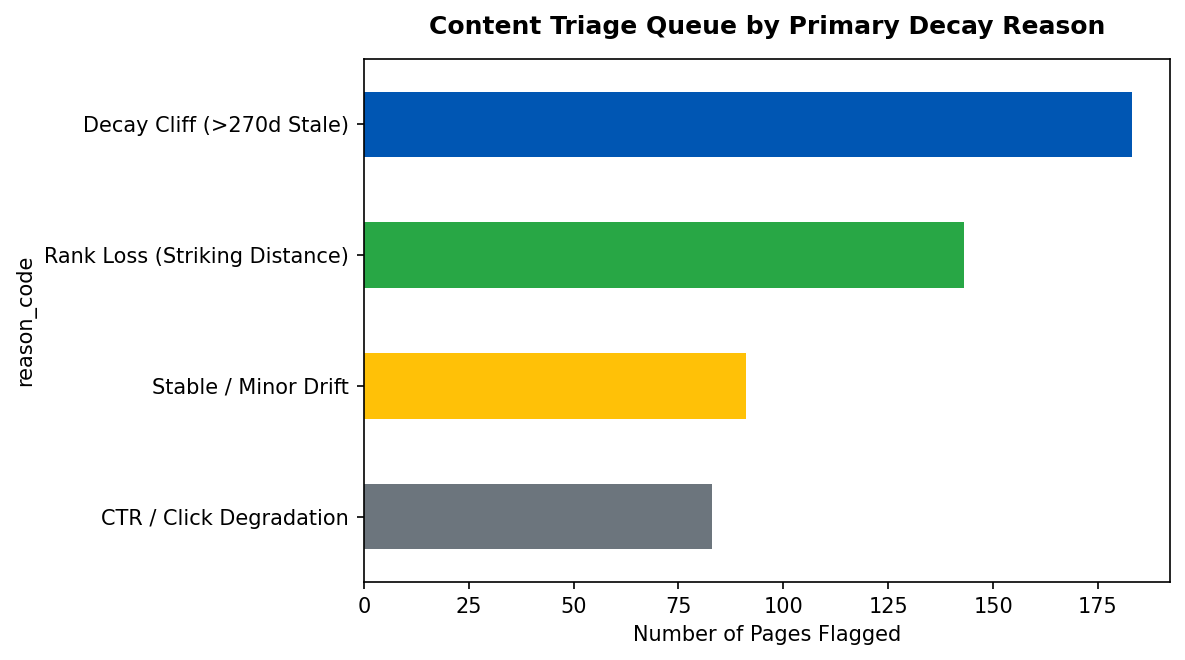

 Saved figure to: work/figures/queue_reason_breakdown.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
reason_counts = ranked_queue['reason_code'].value_counts()
colors = ['#0056b3', '#28a745', '#ffc107', '#6c757d']

reason_counts.plot(kind='barh', ax=ax, color=colors[:len(reason_counts)])
ax.set_title("Content Triage Queue by Primary Decay Reason", fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel("Number of Pages Flagged", fontsize=10)
ax.invert_yaxis()
plt.tight_layout()

figure_path = "work/figures/queue_reason_breakdown.png"
plt.savefig(figure_path)
plt.show()
print(f" Saved figure to: {figure_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.